# Housing Authority Features Multinomial Logistic Regression Model

## Objective
This notebook analyzes the relationship between Housing Authority (HA) features and comment cluster types using multinomial logistic regression.

**Features (Predictors):** Housing Authority characteristics
- Operation expense/unit
- Tenants Left
- Maintenance cost/unit
- Affordability(Rent)/month
- Tenants Repair Request
- Total Housing

**Target Variable:** Cluster_KMeans (Comment type clusters: 0, 1, 2, 3, 4, 5)

**Statistical Method:** Multinomial Logistic Regression

In [34]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("🏠 HOUSING AUTHORITY FEATURES ANALYSIS")
print("=" * 42)
print("📊 Libraries loaded successfully!")

🏠 HOUSING AUTHORITY FEATURES ANALYSIS
📊 Libraries loaded successfully!


In [35]:
# Load Data
print("📂 LOADING DATA")
print("=" * 15)

# Load the dataset with K-means clusters and HA features
data_path = r"C:\Users\20245179\OneDrive - TU Eindhoven\Research Paper\Data\KMeans_filtered_with_HA_feature_levels_top50.csv"
df = pd.read_csv(data_path)

print(f"✅ Data loaded successfully!")
print(f"📊 Dataset shape: {df.shape}")
print(f"🎯 Target variable: Cluster_KMeans")

# Check cluster distribution
cluster_dist = df['Cluster_KMeans'].value_counts().sort_index()
print(f"\n🎯 Cluster Distribution:")
for cluster, count in cluster_dist.items():
    percentage = (count / len(df)) * 100
    print(f"   Cluster {cluster}: {count:,} samples ({percentage:.1f}%)")

print(f"\n📊 Total samples: {len(df):,}")

📂 LOADING DATA
✅ Data loaded successfully!
📊 Dataset shape: (2882, 36)
🎯 Target variable: Cluster_KMeans

🎯 Cluster Distribution:
   Cluster 0: 383 samples (13.3%)
   Cluster 1: 859 samples (29.8%)
   Cluster 2: 146 samples (5.1%)
   Cluster 3: 483 samples (16.8%)
   Cluster 4: 369 samples (12.8%)
   Cluster 5: 642 samples (22.3%)

📊 Total samples: 2,882


In [36]:
df

,Post,Comment,Comments_time,Sentiment,final_label_three_models_final,GRO_NLP_prob_Appreciation,GRO_NLP_prob_Criticism,GRO_NLP_prob_Inquiry,GRO_NLP_prob_Statement,roberta_prob_Appreciation,...,PC2,Author,Number of houses(DAEB),Number of houses(niet_DAEB),Total Housing,Operation expense/unit,Tenants Left,Maintainance cost/unit,Affordability(Rent/month),Tenants Repair Request
0,De zonnepanelen op het dak van ons kantoor doe...,hoeveel KWh hebben de zonnepanelen op de wezen...,2019-04-02 22:14:59,-1,Inquiry,0.010445,0.011370,0.968024,0.010161,0.010267,...,0.732400,WormerWonen,2233.0,41.0,2274.0,1002.0,8.2,2124.0,548.0,7.9
1,IN ACTI-UM | Onze vakmannen vervangen bij iede...,Dan kom ik langs voor sleutels en krijg er gra...,2018-12-21 15:37:26,0,Criticism,0.027336,0.024728,0.752228,0.195707,0.014287,...,0.084632,Actium,15227.0,27.0,15254.0,850.0,7.9,2782.0,535.0,7.8
2,IN ACTI-UM | Onze vakmannen vervangen bij iede...,"Mmmm, iets nieuws? Wij hebben in maart geen wi...",2018-12-21 10:57:48,-1,Statement,0.013757,0.042974,0.139054,0.804214,0.009658,...,-0.716585,Actium,15227.0,27.0,15254.0,850.0,7.9,2782.0,535.0,7.8
3,Luister vandaag om 15.30 uur naar BNR in Bedri...,Kun je zo je vraagtekens bij zetten. Hoe vrijb...,2019-03-06 14:19:27,-1,Inquiry,0.009549,0.009589,0.971615,0.009247,0.009553,...,-0.094540,Accolade,14863.0,363.0,15226.0,907.0,7.4,2570.0,533.0,8.0
4,Ook deze week zijn werklieden volop bezig met ...,... en de Hamwijck ??????,2019-06-17 22:28:48,-1,Statement,0.010635,0.024515,0.023830,0.941020,0.010264,...,-1.111066,Woonforte,9676.0,469.0,10145.0,949.0,7.7,3339.0,556.0,7.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2877,Vorige week zijn de laatste huizen van 't Getf...,Kijk onze wijk <PERSON> <PERSON> Paulo Mariaa ...,2019-07-30 10:57:55,0,Statement,0.040425,0.046785,0.503709,0.409080,0.010718,...,0.173767,De Woonplaats,15287.0,668.0,15955.0,857.0,7.4,2606.0,585.0,7.7
2878,Op de 1e verdieping van het oude schoolgebouw ...,Is er genoeg ventilatie en / of kunnen ramen g...,2020-10-22 12:40:07,0,Inquiry,0.010553,0.010469,0.968225,0.010752,0.010153,...,0.818739,Woongoed Zeist,16105.0,200.0,16305.0,800.0,8.7,3000.0,606.0,7.5
2879,Op de 1e verdieping van het oude schoolgebouw ...,<PERSON> kan je dus straks gebruik van maken. ...,2020-10-21 15:54:40,0,Forward,0.026950,0.707743,0.056919,0.208388,0.014766,...,-0.818682,Woongoed Zeist,16105.0,200.0,16305.0,800.0,8.7,3000.0,606.0,7.5
2880,Op de 1e verdieping van het oude schoolgebouw ...,Komen er nog meer werkplekken bij? Of blijft h...,2020-10-19 10:14:18,-1,Inquiry,0.011488,0.011212,0.966778,0.010522,0.009458,...,0.513431,Woongoed Zeist,16105.0,200.0,16305.0,800.0,8.7,3000.0,606.0,7.5


In [37]:
# unique author count and unique post count
print("👥 UNIQUE COUNTS ANALYSIS")
print("=" * 25)

# Try to find author column
author_col = None
for col_name in ['Author']:
    if col_name in df.columns:
        author_col = col_name
        break

if author_col:
    unique_authors = df[author_col].nunique()
    print(f"👤 Unique Authors: {unique_authors:,}")
    print(f"📊 Comments per author (avg): {len(df)/unique_authors:.1f}")
else:
    print("👤 Author column not found in dataset")

# Try to find post ID column
post_col = None
for col_name in ['Post']:
    if col_name in df.columns:
        post_col = col_name
        break

if post_col:
    unique_posts = df[post_col].nunique()
    print(f"📝 Unique Posts: {unique_posts:,}")
    print(f"💬 Comments per post (avg): {len(df)/unique_posts:.1f}")
else:
    print("📝 Post ID column not found in dataset")

print(f"💬 Total Comments: {len(df):,}")

# Show available columns for reference
print(f"\n📋 Available columns in dataset:")
print(df.columns.tolist())



👥 UNIQUE COUNTS ANALYSIS
👤 Unique Authors: 50
📊 Comments per author (avg): 57.6
📝 Unique Posts: 648
💬 Comments per post (avg): 4.4
💬 Total Comments: 2,882

📋 Available columns in dataset:
['Post', 'Comment', 'Comments_time', 'Sentiment', 'final_label_three_models_final', 'GRO_NLP_prob_Appreciation', 'GRO_NLP_prob_Criticism', 'GRO_NLP_prob_Inquiry', 'GRO_NLP_prob_Statement', 'roberta_prob_Appreciation', 'roberta_prob_Criticism', 'roberta_prob_Inquiry', 'roberta_prob_Statement', 'debertaV3_prob_Appreciation', 'debertaV3_prob_Criticism', 'debertaV3_prob_Inquiry', 'debertaV3_prob_Statement', 'Similarity', 'Similarity_Category', 'avg_prob_Appreciation', 'avg_prob_Criticism', 'avg_prob_Inquiry', 'avg_prob_Statement', 'avg_prob_Forward', 'Cluster_KMeans', 'PC1', 'PC2', 'Author', 'Number of houses(DAEB)', 'Number of houses(niet_DAEB)', 'Total Housing', 'Operation expense/unit', 'Tenants Left', 'Maintainance cost/unit', 'Affordability(Rent/month)', 'Tenants Repair Request']


In [38]:
# Define and Explore HA Features
print("🏠 HOUSING AUTHORITY FEATURES ANALYSIS")
print("=" * 38)

# Define HA features
ha_features = [
    'Operation expense/unit',
    'Tenants Left', 
    'Maintainance cost/unit',
    'Affordability(Rent/month)',
    'Total Housing'
]

print(f"📊 Housing Authority Features ({len(ha_features)}):")
for i, feature in enumerate(ha_features, 1):
    print(f"   {i}. {feature}")

# Check feature availability and basic statistics
print(f"\n📈 Feature Statistics:")
print("-" * 60)

ha_stats = df[ha_features].describe()
print(ha_stats.round(2))

# Check for missing values
missing_values = df[ha_features].isnull().sum()
if missing_values.sum() > 0:
    print(f"\n⚠️  Missing values found:")
    print(missing_values[missing_values > 0])
else:
    print(f"\n✅ No missing values in HA features")

🏠 HOUSING AUTHORITY FEATURES ANALYSIS
📊 Housing Authority Features (5):
   1. Operation expense/unit
   2. Tenants Left
   3. Maintainance cost/unit
   4. Affordability(Rent/month)
   5. Total Housing

📈 Feature Statistics:
------------------------------------------------------------
       Operation expense/unit  Tenants Left  Maintainance cost/unit  \
count                 2882.00       2882.00                 2882.00   
mean                   848.34          7.68                 3171.36   
std                    109.58          0.35                  533.65   
min                    660.00          6.70                 1806.00   
25%                    781.00          7.60                 2782.00   
50%                    838.00          7.70                 3269.00   
75%                    890.00          7.90                 3658.00   
max                   1279.00          8.70                 4008.00   

       Affordability(Rent/month)  Total Housing  
count                    

In [39]:
# Comprehensive Descriptive Statistics Table
print("📊 COMPREHENSIVE DESCRIPTIVE STATISTICS")
print("=" * 40)

# Overall dataset information
print("🏠 DATASET OVERVIEW")
print("-" * 19)
print(f"📊 Total observations (comments): {len(df):,}")

# Count unique housing associations if available
if 'Housing_Authority' in df.columns or 'HA_Name' in df.columns or 'Authority' in df.columns:
    # Try different possible column names for housing authority
    ha_col = None
    for col_name in ['Housing_Authority', 'HA_Name', 'Authority', 'housing_authority']:
        if col_name in df.columns:
            ha_col = col_name
            break
    
    if ha_col:
        unique_has = df[ha_col].nunique()
        print(f"🏢 Number of Housing Associations: {unique_has:,}")
    else:
        print("🏢 Housing Association info: Column not found")
else:
    # If no direct HA column, try to infer from data structure or use a reasonable estimate
    print("🏢 Housing Association info: Not directly available")

# Count unique posts if available
if 'Post_ID' in df.columns or 'post_id' in df.columns or 'PostID' in df.columns:
    # Try different possible column names for post ID
    post_col = None
    for col_name in ['Post_ID', 'post_id', 'PostID', 'post_ID']:
        if col_name in df.columns:
            post_col = col_name
            break
    
    if post_col:
        unique_posts = df[post_col].nunique()
        print(f"📝 Number of Posts: {unique_posts:,}")
    else:
        print("📝 Post info: Column not found")
else:
    print("📝 Post info: Not directly available")

print(f"💬 Number of Comments: {len(df):,}")
print()

# Create descriptive statistics for each HA feature
descriptive_stats = []

for feature in ha_features:
    feature_data = df[feature]
    
    stats = {
        'Feature': feature,
        'Mean': feature_data.mean(),
        'Std_Dev': feature_data.std(),
        'Median': feature_data.median(),
        '33rd_Percentile': feature_data.quantile(0.33),
        '67th_Percentile': feature_data.quantile(0.67),
        'Min': feature_data.min(),
        'Max': feature_data.max(),
        'N': len(feature_data)
    }
    
    descriptive_stats.append(stats)

# Create DataFrame and display
descriptive_df = pd.DataFrame(descriptive_stats)

print("🏠 Housing Authority Features - Detailed Statistics")
print("-" * 60)
print(f"📊 Total observations: {len(df):,}")
print(f"🎯 67th percentile used as High/Low_Medium threshold")
print("\n" + "="*90)

# Display formatted table
for idx, row in descriptive_df.iterrows():
    print(f"\n🏠 {row['Feature']}")
    print("-" * 50)
    print(f"   Mean:           {row['Mean']:>12.2f}")
    print(f"   Std Dev:        {row['Std_Dev']:>12.2f}")
    print(f"   Median:         {row['Median']:>12.2f}")
    print(f"   33rd Percentile:{row['33rd_Percentile']:>12.2f} (Low/Medium boundary)")
    print(f"   67th Percentile:{row['67th_Percentile']:>12.2f} (HIGH threshold) ⭐")
    print(f"   Min:            {row['Min']:>12.2f}")
    print(f"   Max:            {row['Max']:>12.2f}")
    print(f"   N:              {row['N']:>12,}")

# Summary table
print(f"\n📋 SUMMARY TABLE")
print("=" * 90)
summary_table = descriptive_df[['Feature', 'Mean', 'Std_Dev', 'Median', '33rd_Percentile', '67th_Percentile']].round(2)
print(summary_table.to_string(index=False, 
                               formatters={
                                   'Mean': '{:.2f}'.format,
                                   'Std_Dev': '{:.2f}'.format,
                                   'Median': '{:.2f}'.format,
                                   '33rd_Percentile': '{:.2f}'.format,
                                   '67th_Percentile': '{:.2f}'.format
                               }))

# Create distribution insights
print(f"\n🎯 DISTRIBUTION INSIGHTS")
print("-" * 25)
for idx, row in descriptive_df.iterrows():
    cv = (row['Std_Dev'] / row['Mean']) * 100  # Coefficient of variation
    skewness_indicator = "Right-skewed" if row['Mean'] > row['Median'] else "Left-skewed" if row['Mean'] < row['Median'] else "Symmetric"
    
    print(f"📊 {row['Feature']:<30}")
    print(f"   Variability (CV): {cv:>6.1f}%")
    print(f"   Distribution: {skewness_indicator}")
    print(f"   High segment: >{row['67th_Percentile']:.2f} ({100-67:.0f}% of observations)")
    print()

print("✅ Descriptive statistics analysis complete!")

📊 COMPREHENSIVE DESCRIPTIVE STATISTICS
🏠 DATASET OVERVIEW
-------------------
📊 Total observations (comments): 2,882
🏢 Housing Association info: Not directly available
📝 Post info: Not directly available
💬 Number of Comments: 2,882

🏠 Housing Authority Features - Detailed Statistics
------------------------------------------------------------
📊 Total observations: 2,882
🎯 67th percentile used as High/Low_Medium threshold


🏠 Operation expense/unit
--------------------------------------------------
   Mean:                 848.34
   Std Dev:              109.58
   Median:               838.00
   33rd Percentile:      781.00 (Low/Medium boundary)
   67th Percentile:      890.00 (HIGH threshold) ⭐
   Min:                  660.00
   Max:                 1279.00
   N:                     2,882

🏠 Tenants Left
--------------------------------------------------
   Mean:                   7.68
   Std Dev:                0.35
   Median:                 7.70
   33rd Percentile:        7.70 (Low/

In [40]:
# Create Categorical Levels for HA Features
print("🔧 FEATURE ENGINEERING - CATEGORIZATION")
print("=" * 39)

# Create categorical versions using 67th percentile for binary split
df_model = df.copy()

print("📊 Creating Low/Medium and High categories using 67th percentile:")
print("-" * 65)

for feature in ha_features:
    # Calculate 67th percentile as threshold
    q67 = df_model[feature].quantile(0.67)
    
    # Create categorical levels (binary split)
    level_col = f"{feature}_Level"
    df_model[level_col] = pd.cut(
        df_model[feature],
        bins=[-np.inf, q67, np.inf],
        labels=['Low_Medium', 'High']
    )
    
    print(f"✅ {feature}:")
    print(f"   Low/Medium: ≤ {q67:.2f} | High: > {q67:.2f}")
    
    # Show distribution
    level_dist = df_model[level_col].value_counts()
    print(f"   Distribution: Low/Medium: {level_dist['Low_Medium']}, High: {level_dist['High']}")
    print()

# Get categorical feature names
ha_level_features = [f"{feature}_Level" for feature in ha_features]

print(f"✅ Created {len(ha_level_features)} binary categorical HA features")
print(f"📊 Categorical features: {ha_level_features}")

🔧 FEATURE ENGINEERING - CATEGORIZATION
📊 Creating Low/Medium and High categories using 67th percentile:
-----------------------------------------------------------------
✅ Operation expense/unit:
   Low/Medium: ≤ 890.00 | High: > 890.00
   Distribution: Low/Medium: 2225, High: 657

✅ Tenants Left:
   Low/Medium: ≤ 7.80 | High: > 7.80
   Distribution: Low/Medium: 2026, High: 856

✅ Maintainance cost/unit:
   Low/Medium: ≤ 3511.00 | High: > 3511.00
   Distribution: Low/Medium: 2005, High: 877

✅ Affordability(Rent/month):
   Low/Medium: ≤ 573.00 | High: > 573.00
   Distribution: Low/Medium: 1966, High: 916

✅ Total Housing:
   Low/Medium: ≤ 34663.00 | High: > 34663.00
   Distribution: Low/Medium: 1956, High: 926

✅ Created 5 binary categorical HA features
📊 Categorical features: ['Operation expense/unit_Level', 'Tenants Left_Level', 'Maintainance cost/unit_Level', 'Affordability(Rent/month)_Level', 'Total Housing_Level']


In [41]:
# Prepare Data for Multinomial Logistic Regression
print("🔄 DATA PREPARATION FOR MODELING")
print("=" * 33)

# Select features and target
model_data = df_model[ha_level_features + ['Cluster_KMeans']].copy()

print(f"📊 Model data shape: {model_data.shape}")
print(f"🎯 Features: {len(ha_level_features)} HA binary categorical features")
print(f"🎯 Target: Cluster_KMeans")

# One-hot encode categorical features
print(f"\n🔄 Creating dummy variables (one-hot encoding)...")

# Create dummy variables for each categorical feature
dummy_columns = []
for feature in ha_level_features:
    # Create dummy variables (drop 'Low_Medium' category as reference to avoid multicollinearity)
    dummies = pd.get_dummies(model_data[feature], prefix=feature)
    # Drop the 'Low_Medium' category to use as reference
    low_med_col = f"{feature}_Low_Medium"
    if low_med_col in dummies.columns:
        dummies = dummies.drop(columns=[low_med_col])
    dummy_columns.extend(dummies.columns.tolist())
    # Add to model_data
    model_data = pd.concat([model_data, dummies], axis=1)

# Create feature matrix (X) and target vector (y)
X = model_data[dummy_columns].copy()
y = model_data['Cluster_KMeans'].copy()

print(f"✅ Feature matrix shape: {X.shape}")
print(f"📊 Dummy variables created: {len(dummy_columns)}")
print(f"🏠 Reference level for all HA features: 'Low_Medium' (excluded from model)")
print(f"\n📋 Dummy variable columns:")
for i, col in enumerate(dummy_columns, 1):
    print(f"   {i:2d}. {col}")

🔄 DATA PREPARATION FOR MODELING
📊 Model data shape: (2882, 6)
🎯 Features: 5 HA binary categorical features
🎯 Target: Cluster_KMeans

🔄 Creating dummy variables (one-hot encoding)...
✅ Feature matrix shape: (2882, 5)
📊 Dummy variables created: 5
🏠 Reference level for all HA features: 'Low_Medium' (excluded from model)

📋 Dummy variable columns:
    1. Operation expense/unit_Level_High
    2. Tenants Left_Level_High
    3. Maintainance cost/unit_Level_High
    4. Affordability(Rent/month)_Level_High
    5. Total Housing_Level_High


In [42]:
# Clean Data and Prepare for StatsModels
print("🧹 DATA CLEANING FOR STATSMODELS")
print("=" * 33)

# Define cluster name mapping
cluster_name_map = {
    0: 'On-topic Feedbacks',
    1: 'On-topic Criticism', 
    2: 'On-topic Praise',
    3: 'Off-topic Complaints',
    4: 'Content Sharing',
    5: 'Information Seeking'
}

print("🏷️ CLUSTER NAME MAPPING:")
print("-" * 25)
for cluster_num, cluster_name in cluster_name_map.items():
    count = (df_model['Cluster_KMeans'] == cluster_num).sum()
    percentage = (count / len(df_model)) * 100
    print(f"   {cluster_num} → {cluster_name}: {count:,} samples ({percentage:.1f}%)")

# Clean column names for statsmodels compatibility
X_clean = X.astype(float)
column_mapping = {}

for col in X.columns:
    # Remove special characters that might cause issues
    clean_name = col.replace(' ', '_').replace('/', '_').replace('-', '_')
    clean_name = clean_name.replace('(', '').replace(')', '').replace('.', '_')
    # Remove double underscores
    while '__' in clean_name:
        clean_name = clean_name.replace('__', '_')
    clean_name = clean_name.strip('_')
    column_mapping[col] = clean_name

# Apply clean names
X_clean.columns = [column_mapping[col] for col in X.columns]

print(f"\n✅ Column names cleaned for statsmodels")
print(f"📊 Final feature matrix shape: {X_clean.shape}")

# Encode target variable with Information Seeking (cluster 5) as reference
# Reorder so Information Seeking becomes the reference category (class 0)
cluster_order = [5, 0, 1, 2, 3, 4]  # Information Seeking first, then others
y_reordered = y.copy()

# Create mapping from original cluster to new encoding
original_to_new = {cluster_order[i]: i for i in range(len(cluster_order))}
new_to_original = {i: cluster_order[i] for i in range(len(cluster_order))}

# Apply reordering
y_encoded = y_reordered.map(original_to_new).values
class_numbers = np.array([new_to_original[i] for i in range(len(cluster_order))])

# Map to meaningful names with new order
class_names = [cluster_name_map[num] for num in class_numbers]

print(f"\n🎯 Target variable encoding (Information Seeking as baseline):")
for i, (class_num, class_name) in enumerate(zip(class_numbers, class_names)):
    count = (y_encoded == i).sum()
    baseline_note = " (BASELINE)" if class_name == "Information Seeking" else ""
    print(f"   {i} → {class_name} ({count:,} samples){baseline_note}")

# Add constant term for intercept
X_final = sm.add_constant(X_clean)

print(f"\n✅ Final feature matrix with constant: {X_final.shape}")
print(f"📊 Features ready for multinomial logistic regression")
print(f"🏠 HA reference level: 'Low_Medium' (excluded from model)")
print(f"🎯 Cluster baseline: Information Seeking (class 0)")

🧹 DATA CLEANING FOR STATSMODELS
🏷️ CLUSTER NAME MAPPING:
-------------------------
   0 → On-topic Feedbacks: 383 samples (13.3%)
   1 → On-topic Criticism: 859 samples (29.8%)
   2 → On-topic Praise: 146 samples (5.1%)
   3 → Off-topic Complaints: 483 samples (16.8%)
   4 → Content Sharing: 369 samples (12.8%)
   5 → Information Seeking: 642 samples (22.3%)

✅ Column names cleaned for statsmodels
📊 Final feature matrix shape: (2882, 5)

🎯 Target variable encoding (Information Seeking as baseline):
   0 → Information Seeking (642 samples) (BASELINE)
   1 → On-topic Feedbacks (383 samples)
   2 → On-topic Criticism (859 samples)
   3 → On-topic Praise (146 samples)
   4 → Off-topic Complaints (483 samples)
   5 → Content Sharing (369 samples)

✅ Final feature matrix with constant: (2882, 6)
📊 Features ready for multinomial logistic regression
🏠 HA reference level: 'Low_Medium' (excluded from model)
🎯 Cluster baseline: Information Seeking (class 0)


In [43]:
# Fit Multinomial Logistic Regression Model
print("🎯 MULTINOMIAL LOGISTIC REGRESSION MODELING")
print("=" * 44)

print(f"🔄 Training multinomial logistic regression model...")
print(f"📊 Features: {X_final.shape[1] - 1} (+ intercept)")
print(f"🎯 Target classes: {len(class_names)}")
print(f"📝 Baseline cluster: {class_names[0]} (Information Seeking)")
print(f"📊 HA feature reference level: 'Low/Medium' (dropped as reference category)")

try:
    # Fit the multinomial logistic regression model
    model = sm.MNLogit(y_encoded, X_final)
    results = model.fit(disp=True, maxiter=500)
    
    if results.mle_retvals.get('converged', False):
        print("\n✅ Model converged successfully!")
        
        # Model performance metrics
        print(f"\n📊 MODEL PERFORMANCE METRICS")
        print("=" * 29)
        print(f"   📈 Log-Likelihood: {results.llf:.4f}")
        print(f"   📊 AIC: {results.aic:.4f}")
        print(f"   📉 BIC: {results.bic:.4f}")
        print(f"   🎯 Pseudo R-squared: {results.prsquared:.4f}")
        print(f"   🔢 Number of observations: {results.nobs:.0f}")
        print(f"   📊 Number of parameters: {len(results.params)}")
        
        # Store metadata for analysis
        results.class_names = class_names
        results.class_numbers = class_numbers
        results.cluster_name_map = cluster_name_map
        results.feature_names = list(X_final.columns)
        results.original_mapping = column_mapping
        
        print(f"\n✅ Model fitting complete!")
        
        # Show complete model summary
        print(f"\n📋 COMPLETE MODEL SUMMARY")
        print("=" * 26)
        print(results.summary())
        
    else:
        print("\n⚠️  Convergence issues detected. Trying alternative solver...")
        
        # Try with BFGS method
        results = model.fit(method='bfgs', disp=True, maxiter=1000)
        
        print(f"📈 Alternative model - Log-Likelihood: {results.llf:.4f}")
        print(f"🎯 Alternative model - Pseudo R-squared: {results.prsquared:.4f}")
        
        results.class_names = class_names
        results.class_numbers = class_numbers
        results.cluster_name_map = cluster_name_map
        results.feature_names = list(X_final.columns)
        results.original_mapping = column_mapping
        
        print(f"\n📋 COMPLETE MODEL SUMMARY")
        print("=" * 26)
        print(results.summary())
        
except Exception as e:
    print(f"\n❌ Model fitting failed: {e}")
    print(f"🔄 This may be due to data issues or convergence problems")

🎯 MULTINOMIAL LOGISTIC REGRESSION MODELING
🔄 Training multinomial logistic regression model...
📊 Features: 5 (+ intercept)
🎯 Target classes: 6
📝 Baseline cluster: Information Seeking (Information Seeking)
📊 HA feature reference level: 'Low/Medium' (dropped as reference category)
Optimization terminated successfully.
         Current function value: 1.641617
         Iterations 6

✅ Model converged successfully!

📊 MODEL PERFORMANCE METRICS
   📈 Log-Likelihood: -4731.1403
   📊 AIC: 9522.2806
   📉 BIC: 9701.2678
   🎯 Pseudo R-squared: 0.0212
   🔢 Number of observations: 2882
   📊 Number of parameters: 6

✅ Model fitting complete!

📋 COMPLETE MODEL SUMMARY
                          MNLogit Regression Results                          
Dep. Variable:                      y   No. Observations:                 2882
Model:                        MNLogit   Df Residuals:                     2852
Method:                           MLE   Df Model:                           25
Date:                S

In [44]:
# Detailed Statistical Results Analysis
print("📊 DETAILED STATISTICAL RESULTS")
print("=" * 32)

if 'results' in locals() and results is not None:
    
    # Extract model components
    feature_names = results.feature_names[1:]  # Exclude 'const'
    class_names_analysis = results.class_names
    class_numbers_analysis = results.class_numbers
    cluster_mapping = results.cluster_name_map
    
    print(f"🎯 Reference Category: {class_names_analysis[0]} (Cluster {class_numbers_analysis[0]})")
    print(f"📊 Features analyzed: {len(feature_names)}")
    
    # Check if p-values are available
    try:
        params_matrix = results.params.values
        pvalues_matrix = results.pvalues.values  
        bse_matrix = results.bse.values
        has_pvalues = True
        print(f"✅ P-values available for significance testing")
    except:
        params_matrix = results.params.values
        has_pvalues = False
        print(f"⚠️  P-values not available - showing coefficients only")
    
    # Store detailed results
    detailed_results = []
    significant_by_cluster = {}
    
    print(f"\n📊 COEFFICIENT ANALYSIS BY CLUSTER COMPARISON")
    print("=\" * 48")
    
    # Analyze each cluster vs reference
    for cluster_idx, (cluster_num, cluster_name) in enumerate(zip(class_numbers_analysis[1:], class_names_analysis[1:])):
        
        print(f"\n🎯 **{cluster_name.upper()} (Cluster {cluster_num})** vs **{class_names_analysis[0].upper()} (Cluster {class_numbers_analysis[0]})**")
        print("-" * 80)
        
        # Extract coefficients for this cluster
        cluster_coeffs = params_matrix[1:, cluster_idx]  # Skip intercept
        
        if has_pvalues:
            cluster_pvals = pvalues_matrix[1:, cluster_idx]
            cluster_se = bse_matrix[1:, cluster_idx]
        
        significant_features = []
        
        # Analyze each feature
        for feat_idx, feature_name in enumerate(feature_names):
            coeff = cluster_coeffs[feat_idx]
            
            if has_pvalues:
                p_val = cluster_pvals[feat_idx]
                std_err = cluster_se[feat_idx]
                
                # Determine significance level
                if p_val < 0.001:
                    sig_symbol = "***"
                elif p_val < 0.01:
                    sig_symbol = "**"
                elif p_val < 0.05:
                    sig_symbol = "*"
                elif p_val < 0.1:
                    sig_symbol = "."
                else:
                    sig_symbol = ""
                
                is_significant = p_val < 0.05
                
                # Calculate odds ratio
                odds_ratio = np.exp(coeff)
                
                # Store results
                detailed_results.append({
                    'Cluster_Number': cluster_num,
                    'Cluster_Name': cluster_name,
                    'Cluster_Comparison': f'{cluster_name}_vs_{class_names_analysis[0]}',
                    'Feature': feature_name,
                    'Coefficient': coeff,
                    'Odds_Ratio': odds_ratio,
                    'Std_Error': std_err,
                    'P_value': p_val,
                    'Significance_Symbol': sig_symbol,
                    'Significant': is_significant
                })
                
                if is_significant:
                    significant_features.append({
                        'feature': feature_name,
                        'coeff': coeff,
                        'odds_ratio': odds_ratio,
                        'p_val': p_val,
                        'sig': sig_symbol
                    })
            
            else:
                # Without p-values, consider large coefficients as "significant"
                is_significant = abs(coeff) > 0.1
                odds_ratio = np.exp(coeff)
                
                detailed_results.append({
                    'Cluster_Number': cluster_num,
                    'Cluster_Name': cluster_name,
                    'Cluster_Comparison': f'{cluster_name}_vs_{class_names_analysis[0]}',
                    'Feature': feature_name,
                    'Coefficient': coeff,
                    'Odds_Ratio': odds_ratio,
                    'Std_Error': None,
                    'P_value': None,
                    'Significance_Symbol': '',
                    'Significant': is_significant
                })
                
                if is_significant:
                    significant_features.append({
                        'feature': feature_name,
                        'coeff': coeff,
                        'odds_ratio': odds_ratio,
                        'p_val': None,
                        'sig': ''
                    })
        
        # Display significant features for this cluster
        if significant_features:
            # Sort by coefficient magnitude
            significant_features.sort(key=lambda x: abs(x['coeff']), reverse=True)
            
            print(f"📈 Significant features ({len(significant_features)} found):")
            for feat in significant_features:
                direction = "↑ INCREASES" if feat['coeff'] > 0 else "↓ DECREASES"
                if has_pvalues:
                    print(f"   🏠 {direction} likelihood of {cluster_name}:")
                    print(f"      • {feat['feature']:<35} | Coeff: {feat['coeff']:8.4f} | OR: {feat['odds_ratio']:6.3f} | p: {feat['p_val']:6.4f} {feat['sig']}")
                else:
                    print(f"   🏠 {direction} likelihood of {cluster_name}:")
                    print(f"      • {feat['feature']:<35} | Coeff: {feat['coeff']:8.4f} | OR: {feat['odds_ratio']:6.3f}")
            
            significant_by_cluster[f"{cluster_name} (#{cluster_num})"] = len(significant_features)
        else:
            print(f"   ℹ️  No significant features found at α = 0.05 level")
            significant_by_cluster[f"{cluster_name} (#{cluster_num})"] = 0
    
    # Create results DataFrame
    results_df = pd.DataFrame(detailed_results)
    
    print(f"\n🎉 Statistical analysis complete with meaningful cluster names!")
    
else:
    print("❌ No model results available for analysis")

📊 DETAILED STATISTICAL RESULTS
🎯 Reference Category: Information Seeking (Cluster 5)
📊 Features analyzed: 5
✅ P-values available for significance testing

📊 COEFFICIENT ANALYSIS BY CLUSTER COMPARISON
=" * 48

🎯 **ON-TOPIC FEEDBACKS (Cluster 0)** vs **INFORMATION SEEKING (Cluster 5)**
--------------------------------------------------------------------------------
📈 Significant features (1 found):
   🏠 ↑ INCREASES likelihood of On-topic Feedbacks:
      • Total_Housing_Level_High            | Coeff:   0.4996 | OR:  1.648 | p: 0.0019 **

🎯 **ON-TOPIC CRITICISM (Cluster 1)** vs **INFORMATION SEEKING (Cluster 5)**
--------------------------------------------------------------------------------
📈 Significant features (2 found):
   🏠 ↑ INCREASES likelihood of On-topic Criticism:
      • Total_Housing_Level_High            | Coeff:   0.3172 | OR:  1.373 | p: 0.0164 *
   🏠 ↓ DECREASES likelihood of On-topic Criticism:
      • Operation_expense_unit_Level_High   | Coeff:  -0.3127 | OR:  0.731 |

In [45]:
# Model Summary and Interpretation
print("📋 MODEL SUMMARY AND INTERPRETATION")
print("=" * 36)

if 'results_df' in locals():
    
    # Overall statistics
    total_relationships = len(results_df)
    significant_relationships = results_df['Significant'].sum()
    significance_rate = (significant_relationships / total_relationships) * 100
    
    print(f"📊 OVERALL MODEL STATISTICS")
    print("-" * 27)
    print(f"   🔢 Total feature-cluster relationships: {total_relationships}")
    print(f"   🎯 Significant relationships: {significant_relationships}")
    print(f"   📈 Overall significance rate: {significance_rate:.1f}%")
    print(f"   📊 Model fit (Pseudo R²): {results.prsquared:.4f} ({results.prsquared*100:.2f}% variance explained)")
    
    # Significance by cluster with meaningful names
    print(f"\n🎯 SIGNIFICANT FEATURES BY CLUSTER")
    print("-" * 34)
    for cluster_key, count in significant_by_cluster.items():
        print(f"   {cluster_key}: {count} significant features")
    
    # Most important features overall
    print(f"\n🏆 MOST IMPORTANT FEATURES (by average |coefficient|)")
    print("-" * 53)
    
    feature_importance = results_df.groupby('Feature')['Coefficient'].apply(
        lambda x: abs(x).mean()
    ).sort_values(ascending=False)
    
    print("   Top 10 most influential HA features:")
    for i, (feature, importance) in enumerate(feature_importance.head(10).items(), 1):
        print(f"   {i:2d}. {feature:<40} | Avg |Coeff|: {importance:.4f}")
    
    # Show highest odds ratios
    print(f"\n🎯 HIGHEST ODDS RATIOS (OR > 2.0)")
    print("-" * 32)
    high_odds = results_df[results_df['Odds_Ratio'] > 2.0].nlargest(10, 'Odds_Ratio')
    if len(high_odds) > 0:
        print("   Features with strongest positive associations:")
        for _, row in high_odds.iterrows():
            print(f"   • {row['Feature']:<35} | OR: {row['Odds_Ratio']:6.3f} | {row['Cluster_Name']}")
    else:
        print("   No odds ratios > 2.0 found")
    
    # Show lowest odds ratios (strong negative associations)
    print(f"\n🎯 LOWEST ODDS RATIOS (OR < 0.5)")
    print("-" * 33)
    low_odds = results_df[results_df['Odds_Ratio'] < 0.5].nsmallest(10, 'Odds_Ratio')
    if len(low_odds) > 0:
        print("   Features with strongest negative associations:")
        for _, row in low_odds.iterrows():
            print(f"   • {row['Feature']:<35} | OR: {row['Odds_Ratio']:6.3f} | {row['Cluster_Name']}")
    else:
        print("   No odds ratios < 0.5 found")
    
    # Cluster-specific insights
    print(f"\n🔍 CLUSTER-SPECIFIC INSIGHTS")
    print("-" * 28)
    
    for cluster_name in results_df['Cluster_Name'].unique():
        cluster_data = results_df[results_df['Cluster_Name'] == cluster_name]
        significant_count = cluster_data['Significant'].sum()
        cluster_num = cluster_data['Cluster_Number'].iloc[0]
        
        print(f"\n   📌 {cluster_name} (Cluster {cluster_num}):")
        if significant_count > 0:
            top_features = cluster_data[cluster_data['Significant']].nlargest(3, 'Coefficient')
            print(f"      • {significant_count} significant features")
            print(f"      • Top positive influences:")
            for _, row in top_features.iterrows():
                print(f"        - {row['Feature']}: {row['Coefficient']:.4f} {row['Significance_Symbol']}")
        else:
            print(f"      • No significant HA features found")
    
    # Statistical significance summary
    if has_pvalues:
        print(f"\n📊 STATISTICAL SIGNIFICANCE SUMMARY")
        print("-" * 35)
        
        sig_levels = {
            'p < 0.001 (***)': (results_df['P_value'] < 0.001).sum(),
            'p < 0.01 (**)': ((results_df['P_value'] < 0.01) & (results_df['P_value'] >= 0.001)).sum(),
            'p < 0.05 (*)': ((results_df['P_value'] < 0.05) & (results_df['P_value'] >= 0.01)).sum(),
            'p < 0.1 (.)': ((results_df['P_value'] < 0.1) & (results_df['P_value'] >= 0.05)).sum()
        }
        
        for level, count in sig_levels.items():
            print(f"   {level}: {count} relationships")
    
    print(f"\n✅ Analysis complete! Results stored in 'results_df' DataFrame with cluster names")
    
else:
    print("❌ No results available for summary")

📋 MODEL SUMMARY AND INTERPRETATION
📊 OVERALL MODEL STATISTICS
---------------------------
   🔢 Total feature-cluster relationships: 25
   🎯 Significant relationships: 11
   📈 Overall significance rate: 44.0%
   📊 Model fit (Pseudo R²): 0.0212 (2.12% variance explained)

🎯 SIGNIFICANT FEATURES BY CLUSTER
----------------------------------
   On-topic Feedbacks (#0): 1 significant features
   On-topic Criticism (#1): 2 significant features
   On-topic Praise (#2): 1 significant features
   Off-topic Complaints (#3): 2 significant features
   Content Sharing (#4): 5 significant features

🏆 MOST IMPORTANT FEATURES (by average |coefficient|)
-----------------------------------------------------
   Top 10 most influential HA features:
    1. Total_Housing_Level_High                 | Avg |Coeff|: 0.6002
    2. AffordabilityRent_month_Level_High       | Avg |Coeff|: 0.2524
    3. Tenants_Left_Level_High                  | Avg |Coeff|: 0.2443
    4. Maintainance_cost_unit_Level_High        | A

📊 VISUALIZATION OF RESULTS


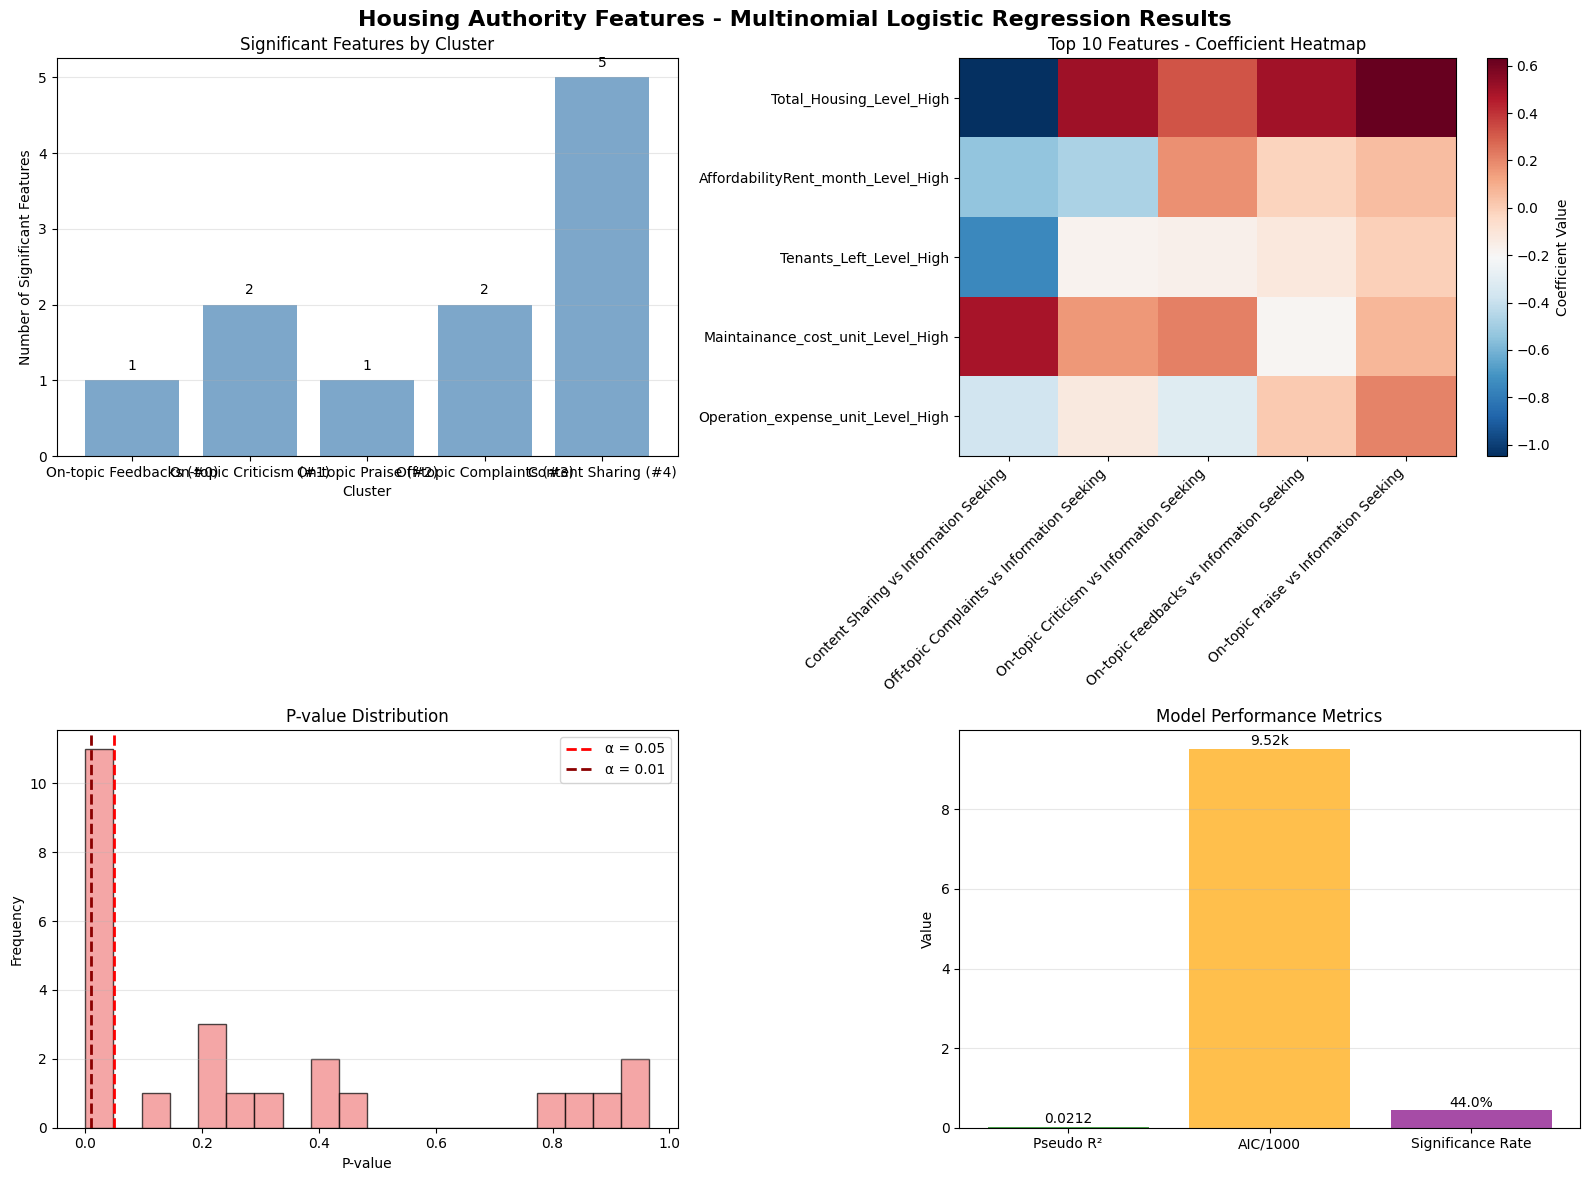

✅ Visualizations generated successfully!

📊 CREATING PREDICTED PROBABILITIES HEATMAP
----------------------------------------------


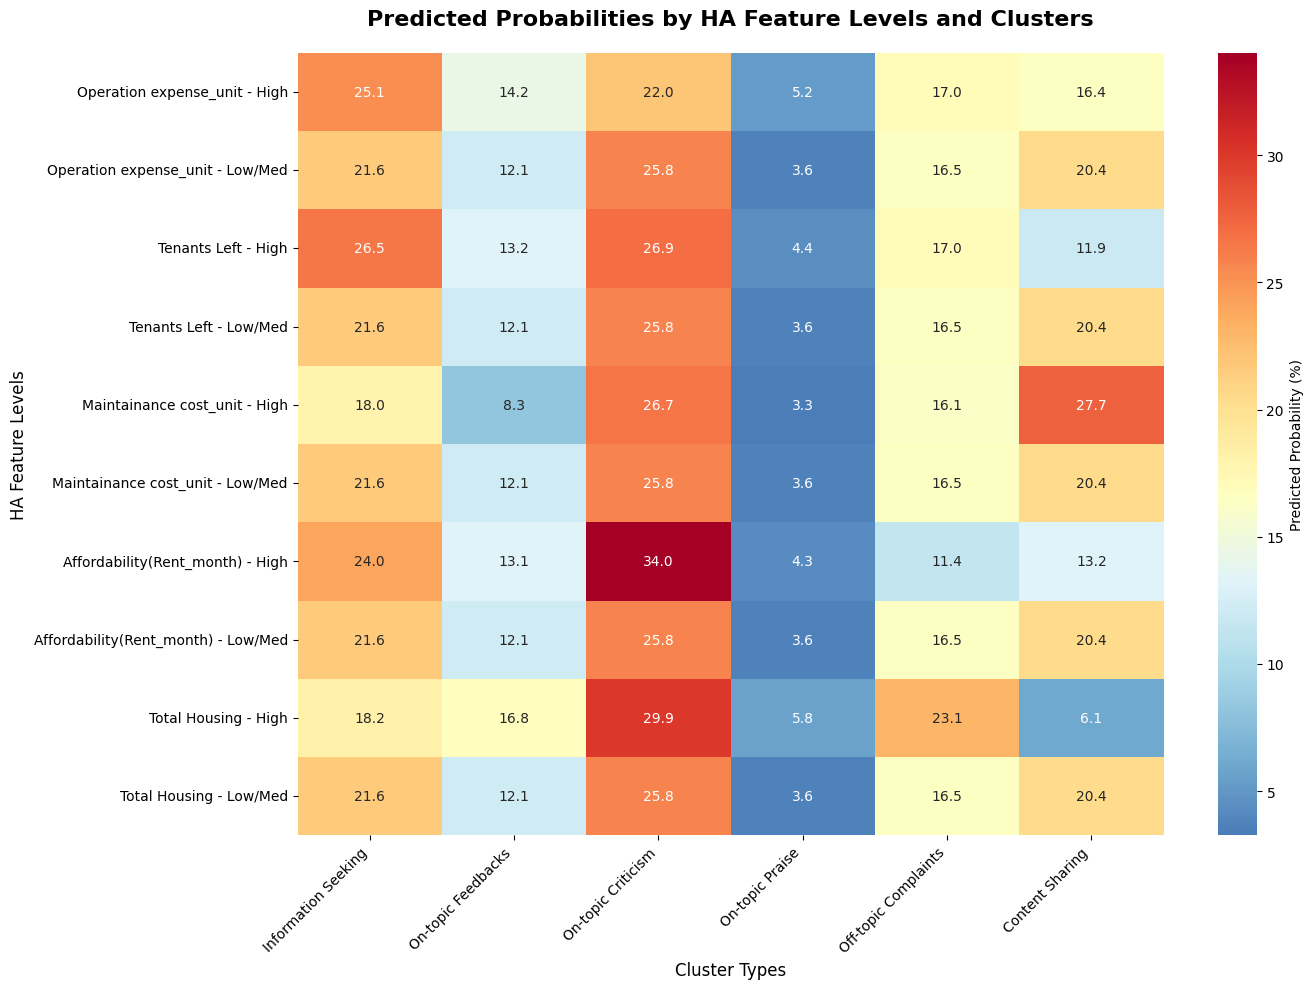

✅ Predicted probabilities heatmap created!
📊 Showing predicted probabilities for 10 HA feature scenarios
🎯 Baseline comparison: Information Seeking cluster


In [46]:
# Visualization of Results
print("📊 VISUALIZATION OF RESULTS")
print("=" * 27)

if 'results_df' in locals():
    
    # Create visualization
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Housing Authority Features - Multinomial Logistic Regression Results', 
                 fontsize=16, fontweight='bold')
    
    # 1. Significant features by cluster
    ax1 = axes[0, 0]
    clusters = list(significant_by_cluster.keys())
    sig_counts = list(significant_by_cluster.values())
    
    bars1 = ax1.bar(clusters, sig_counts, color='steelblue', alpha=0.7)
    ax1.set_title('Significant Features by Cluster')
    ax1.set_xlabel('Cluster')
    ax1.set_ylabel('Number of Significant Features')
    ax1.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar in bars1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{int(height)}', ha='center', va='bottom')
    
    # 2. Feature importance heatmap
    ax2 = axes[0, 1]
    
    # Create coefficient matrix for heatmap
    coeff_matrix = results_df.pivot(index='Feature', columns='Cluster_Comparison', values='Coefficient')
    
    # Plot heatmap with top 10 features
    top_features = feature_importance.head(10).index
    coeff_subset = coeff_matrix.loc[top_features]
    
    im = ax2.imshow(coeff_subset.values, cmap='RdBu_r', aspect='auto')
    ax2.set_title('Top 10 Features - Coefficient Heatmap')
    ax2.set_xticks(range(len(coeff_subset.columns)))
    ax2.set_xticklabels([col.replace('_vs_', ' vs ') for col in coeff_subset.columns], 
                       rotation=45, ha='right')
    ax2.set_yticks(range(len(top_features)))
    ax2.set_yticklabels(top_features, fontsize=10)
    
    # Add colorbar
    plt.colorbar(im, ax=ax2, label='Coefficient Value')
    
    # 3. P-value distribution (if available)
    ax3 = axes[1, 0]
    
    if has_pvalues:
        pvals = results_df['P_value'].dropna()
        ax3.hist(pvals, bins=20, alpha=0.7, color='lightcoral', edgecolor='black')
        ax3.axvline(0.05, color='red', linestyle='--', linewidth=2, label='α = 0.05')
        ax3.axvline(0.01, color='darkred', linestyle='--', linewidth=2, label='α = 0.01')
        ax3.set_title('P-value Distribution')
        ax3.set_xlabel('P-value')
        ax3.set_ylabel('Frequency')
        ax3.legend()
        ax3.grid(axis='y', alpha=0.3)
    else:
        ax3.text(0.5, 0.5, 'P-values not available', 
                transform=ax3.transAxes, ha='center', va='center', fontsize=14)
        ax3.set_title('P-value Distribution')
    
    # 4. Model performance summary
    ax4 = axes[1, 1]
    
    # Performance metrics
    metrics = {
        'Pseudo R²': results.prsquared,
        'AIC/1000': results.aic / 1000,  # Scale for visibility
        'Significance Rate': significance_rate / 100  # Convert to proportion
    }
    
    metric_names = list(metrics.keys())
    metric_values = list(metrics.values())
    
    bars4 = ax4.bar(metric_names, metric_values, 
                   color=['green', 'orange', 'purple'], alpha=0.7)
    ax4.set_title('Model Performance Metrics')
    ax4.set_ylabel('Value')
    ax4.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for i, bar in enumerate(bars4):
        height = bar.get_height()
        if metric_names[i] == 'AIC/1000':
            label = f'{height:.2f}k'
        elif metric_names[i] == 'Significance Rate':
            label = f'{height*100:.1f}%'
        else:
            label = f'{height:.4f}'
        
        ax4.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                label, ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Visualizations generated successfully!")
    
    # Additional Heatmap: Predicted Probabilities for HA Feature Combinations
    print("\n📊 CREATING PREDICTED PROBABILITIES HEATMAP")
    print("-" * 46)
    
    # Create all combinations of HA feature levels
    feature_combinations = []
    feature_labels = []
    
    # For each HA feature, create Low_Medium and High scenarios
    for feature in ha_features:
        # Scenario 1: All features at Low_Medium except this one at High
        scenario_high = {f"{feat}_Level": 'Low_Medium' for feat in ha_features}
        scenario_high[f"{feature}_Level"] = 'High'
        
        # Convert to dummy variables format for prediction
        dummy_high = []
        for feat in ha_features:
            level_col = f"{feat}_Level"
            if scenario_high[level_col] == 'High':
                dummy_high.append(1)  # High level
            else:
                dummy_high.append(0)  # Low_Medium level (reference)
        
        feature_combinations.append(dummy_high)
        feature_labels.append(f"{feature.replace('/', '_')} - High")
        
        # Scenario 2: All features at Low_Medium (baseline)
        dummy_low_med = [0] * len(ha_features)  # All Low_Medium
        feature_combinations.append(dummy_low_med)
        feature_labels.append(f"{feature.replace('/', '_')} - Low/Med")
    
    # Convert to array and add constant
    X_scenarios = np.array(feature_combinations)
    X_scenarios_with_const = np.column_stack([np.ones(X_scenarios.shape[0]), X_scenarios])
    
    # Predict probabilities
    predicted_probs = results.predict(X_scenarios_with_const)
    
    # Create DataFrame for heatmap
    prob_df = pd.DataFrame(
        predicted_probs * 100,  # Convert to percentages
        index=feature_labels,
        columns=[cluster_name_map[class_numbers[i]] for i in range(len(class_names))]
    )
    
    # Create the heatmap
    plt.figure(figsize=(14, 10))
    sns.heatmap(
        prob_df,
        annot=True,
        fmt='.1f',
        cmap='RdYlBu_r',
        center=16.67,  # Center around equal probability (100%/6 clusters)
        cbar_kws={'label': 'Predicted Probability (%)'}
    )
    
    plt.title('Predicted Probabilities by HA Feature Levels and Clusters', 
              fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Cluster Types', fontsize=12)
    plt.ylabel('HA Feature Levels', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    print("✅ Predicted probabilities heatmap created!")
    print(f"📊 Showing predicted probabilities for {len(feature_labels)} HA feature scenarios")
    print(f"🎯 Baseline comparison: Information Seeking cluster")
    
else:
    print("❌ No data available for visualization")